In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
df = pd.read_csv("bank-additional-full.csv",sep=";")

In [3]:
df["y"] = df["y"].map({"yes":1,"no":0})
num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
num_cols.remove("y")
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()

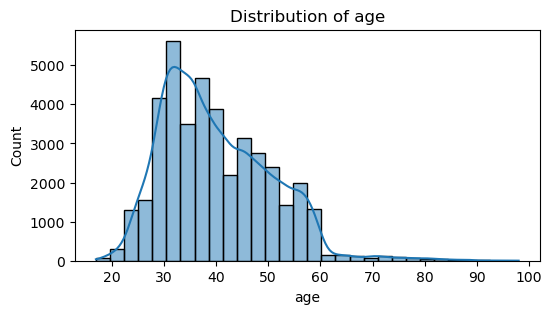

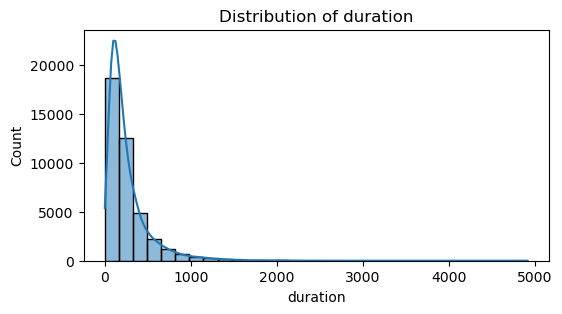

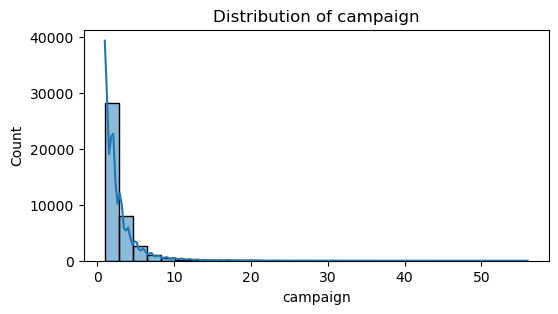

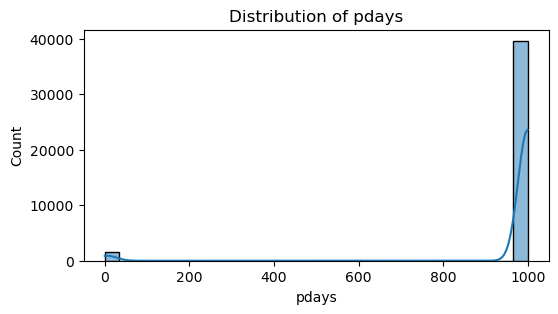

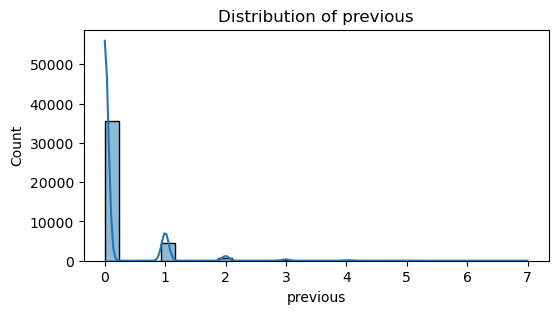

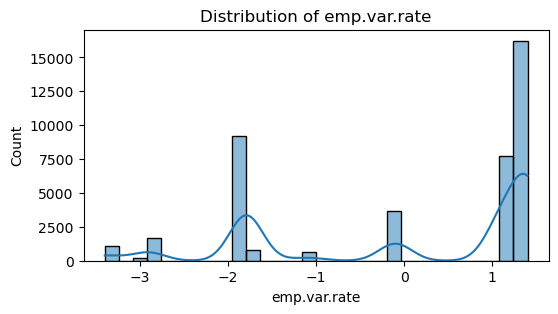

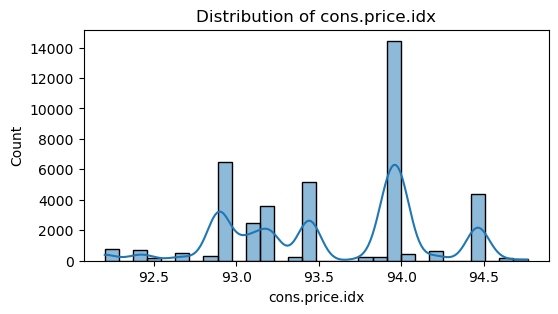

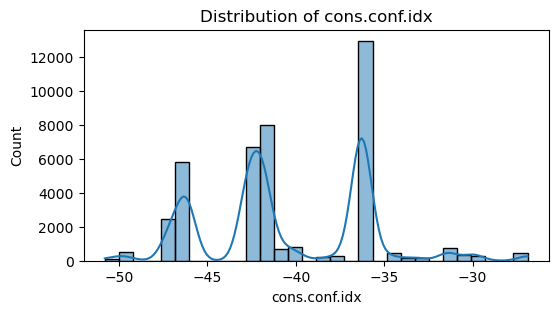

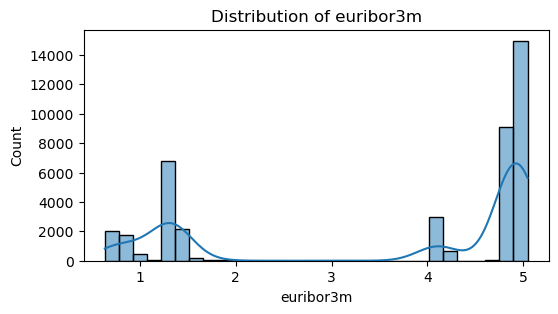

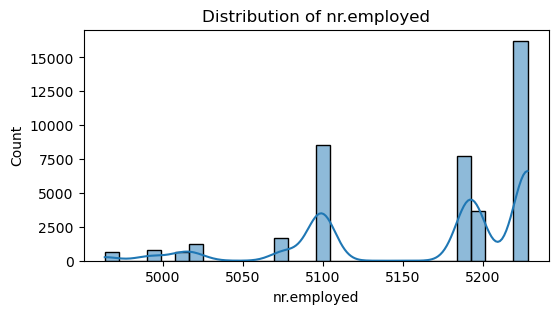

In [4]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col],kde = True,bins = 30)
    plt.title(f'Distribution of {col}')
    plt.show()

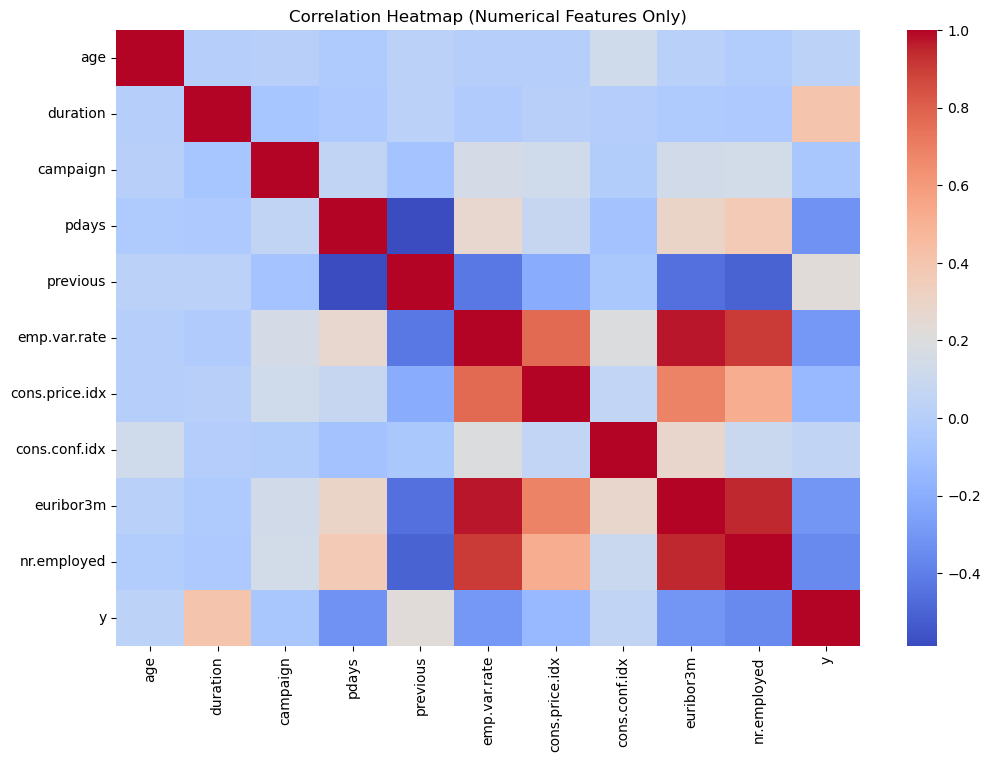

In [5]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

In [6]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
df = pd.get_dummies(df,columns = cat_cols,drop_first = True)

In [8]:
df = df.astype(int)

In [9]:
print(df.columns.tolist())

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']


In [10]:
for col in num_cols:
    df[col] = (df[col]-df[col].mean())/df[col].std()

In [11]:
X = df.drop("y",axis = 1).to_numpy()
y = df["y"].to_numpy()

In [12]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [13]:
x_train = x_train.astype(float)
x_test = x_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [15]:
def sigmoid(z):
    #z = np.array(z)
    z = np.atleast_1d(z)
    return 1/(1+np.exp(-z))

In [16]:
def calculate_cost(X,y,w,b):
    m = y.shape[0]
    z = np.dot(X,w)+b
    h = sigmoid(z)
    eps = 1e-9
    cost = -(1/m) * np.sum(y * np.log(h+eps) + (1-y) * np.log(1-h+eps))
    return cost

In [17]:
def calculate_gradient(X,y,w,b,alpha,iterations):
    m = y.shape[0]
    cost_history = []
    for i in range(iterations):
        z = np.dot(X, w) + b
        h = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (h - y))
        db = (1/m) * np.sum(h - y)
        w = w - alpha * dw
        b = b - alpha * db
        
        if i % 1000 == 0:  
            cost = calculate_cost(X, y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i}: Cost = {cost:.4f}")
            
    return w, b, cost_history

In [18]:
def predict(X,w,b):
    z = np.dot(X,w) + b
    probs = sigmoid(z)
    return (probs>0.33).astype(int)

In [19]:
n = x_train.shape[1]
w = np.zeros(n,dtype=float)
b = 0.0
alpha = 0.04
iterations = 40000


In [20]:
w,b,cost_history = calculate_gradient(x_train,y_train,w,b,alpha,iterations)

Iteration 0: Cost = 0.6698
Iteration 1000: Cost = 0.2174
Iteration 2000: Cost = 0.2151
Iteration 3000: Cost = 0.2140
Iteration 4000: Cost = 0.2132
Iteration 5000: Cost = 0.2126
Iteration 6000: Cost = 0.2121
Iteration 7000: Cost = 0.2117
Iteration 8000: Cost = 0.2114
Iteration 9000: Cost = 0.2111
Iteration 10000: Cost = 0.2109
Iteration 11000: Cost = 0.2107
Iteration 12000: Cost = 0.2105
Iteration 13000: Cost = 0.2103
Iteration 14000: Cost = 0.2102
Iteration 15000: Cost = 0.2101
Iteration 16000: Cost = 0.2100
Iteration 17000: Cost = 0.2099
Iteration 18000: Cost = 0.2098
Iteration 19000: Cost = 0.2097
Iteration 20000: Cost = 0.2097
Iteration 21000: Cost = 0.2096
Iteration 22000: Cost = 0.2096
Iteration 23000: Cost = 0.2095
Iteration 24000: Cost = 0.2095
Iteration 25000: Cost = 0.2094
Iteration 26000: Cost = 0.2094
Iteration 27000: Cost = 0.2094
Iteration 28000: Cost = 0.2093
Iteration 29000: Cost = 0.2093
Iteration 30000: Cost = 0.2093
Iteration 31000: Cost = 0.2092
Iteration 32000: Cost

In [21]:
y_test_pred = predict(x_test,w,b)
test_acc = accuracy_score(y_test,y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9118


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [23]:
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print(f"Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1-Score: {test_f1:.4f}")


Precision: 0.6135, Recall: 0.6011, F1-Score: 0.6072


In [24]:
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

Test ROC-AUC: 0.7763


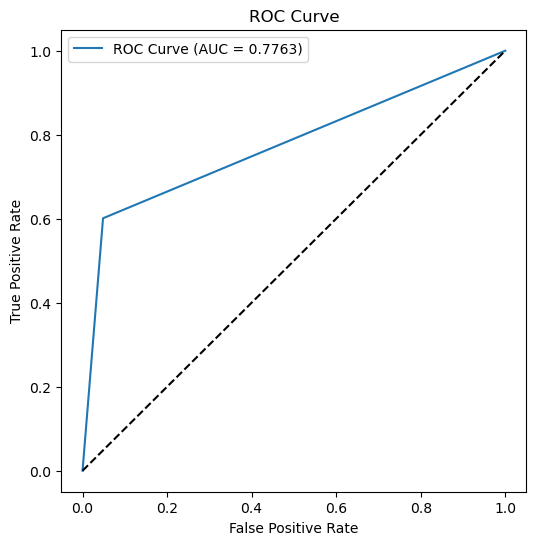

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
#print(df)

In [27]:
cm = confusion_matrix(y_test,y_test_pred)
print(cm)

[[6949  354]
 [ 373  562]]


Best Threshold: 0.236


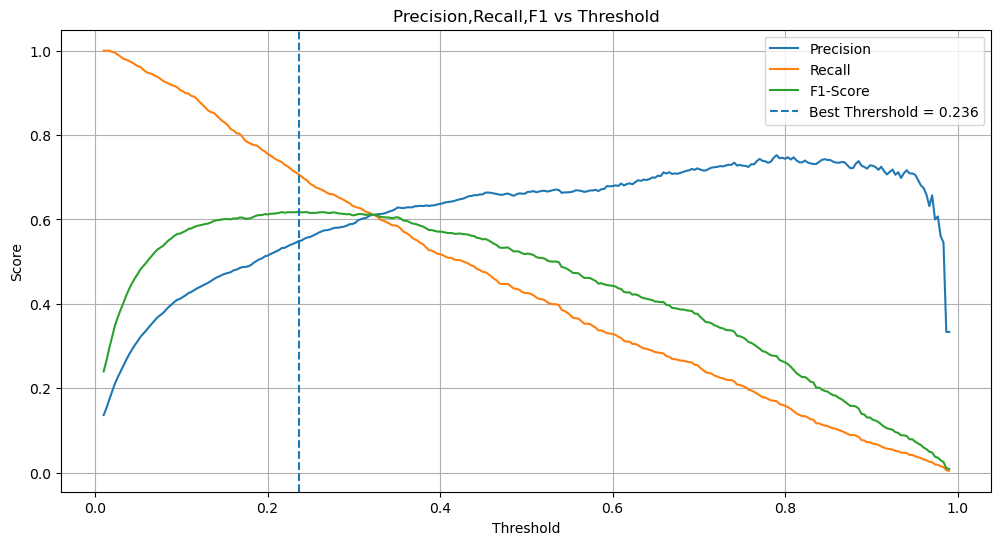

In [28]:
z_test = np.dot(x_test, w) + b
y_prob = sigmoid(z_test)
thresholds = np.linspace(0.01, 0.99, 300)
precisions = []
recalls = []
f1_scores = []
for t in thresholds:
    y_t_pred = (y_prob>=t).astype(int)
    precisions.append(precision_score(y_test,y_t_pred))
    recalls.append(recall_score(y_test,y_t_pred))
    f1_scores.append(f1_score(y_test,y_t_pred))

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
print(f"Best Threshold: {best_threshold:.3f}")
plt.figure(figsize=(12,6))
plt.plot(thresholds,precisions,label="Precision")
plt.plot(thresholds,recalls,label="Recall")
plt.plot(thresholds,f1_scores,label="F1-Score")
plt.axvline(best_threshold,linestyle = "--",label = f"Best Thrershold = {best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision,Recall,F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print(min(y_prob), max(y_prob))

0.000757549556624772 0.999998730384155
